In [ ]:
# **Hidratación Diaria: Ingeniería de Datos, Feature Selection, Pycaret y Ensamble**

In [ ]:
#Instalar la libreria
#!pip install -U pycaret

152.35s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
  Using cached ipywidgets-8.1.9-py3-none-any.whl.metadata (2.4 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... |anceled
ERROR: Operation cancelled by user
^C


In [1]:
#importar librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import VotingClassifier
from pycaret.classification import ClassificationExperiment

In [2]:
#Descargar la ultima version del dataset
path = kagglehub.dataset_download("sonalshinde123/daily-water-intake-and-hydration-patterns-dataset")
print("Path to dataset files:", path)

100%|██████████| 192k/192k [00:00<00:00, 6.45MB/s]

Extracting files...
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/sonalshinde123/daily-water-intake-and-hydration-patterns-dataset/versions/1


In [3]:
#Importar los datos
df = pd.read_csv(path + '/Daily_Water_Intake.csv')
print(df.shape)
df.sample(5)

(30000, 7)


,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
2000,45,Male,46,1.89,High,Normal,Good
16601,61,Female,51,3.00,High,Hot,Good
19639,48,Female,48,2.80,High,Hot,Good
5707,46,Male,53,2.77,High,Normal,Good
20477,42,Female,68,2.79,Moderate,Hot,Good


In [ ]:
# **Ingeniería de Datos**

In [4]:
#Guardar tamaño inicial de base
tam_ini = df.shape[0]
tam_ini

30000

In [5]:
#Determina el valor exacto de datos vacios por columna
df.isna().sum()

Age                            0
Gender                         0
Weight (kg)                    0
Daily Water Intake (liters)    0
Physical Activity Level        0
Weather                        0
Hydration Level                0
dtype: int64

In [6]:
#valida si el tipo de datos es correcto por columna
df.dtypes

Age                              int64
Gender                          object
Weight (kg)                      int64
Daily Water Intake (liters)    float64
Physical Activity Level         object
Weather                         object
Hydration Level                 object
dtype: object

In [7]:
#duplicados: verificar la existencia
df.duplicated(subset=df.columns).sum()

338

In [8]:
#Borramos los Duplicados
df = df.drop_duplicates(subset=df.columns)
print(df.shape)
print('Eliminamos {} registros'.format(tam_ini-df.shape[0]))
df.sample(5)

(29662, 7)
Eliminamos 338 registros


,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
6003,66,Female,62,1.50,Low,Cold,Poor
28697,53,Female,109,4.39,High,Hot,Good
6588,34,Male,98,2.25,Low,Cold,Poor
12628,60,Male,70,2.09,Low,Hot,Poor
3385,32,Male,46,1.50,Low,Cold,Good


<Axes: >

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

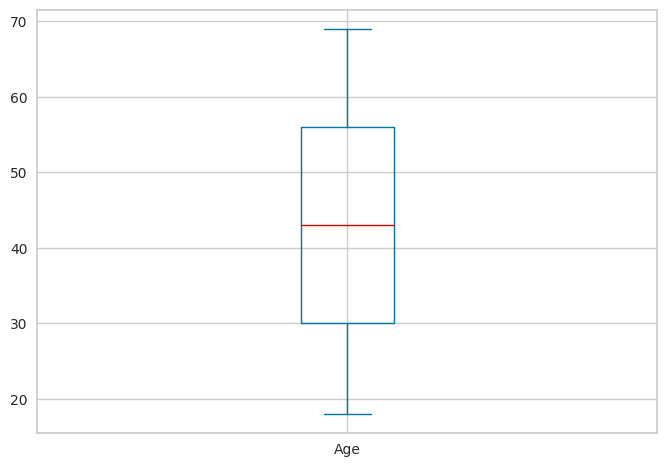

In [9]:
#exploramos la presencia de outliers: Age
df['Age'].plot(kind='box')

<Axes: >

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

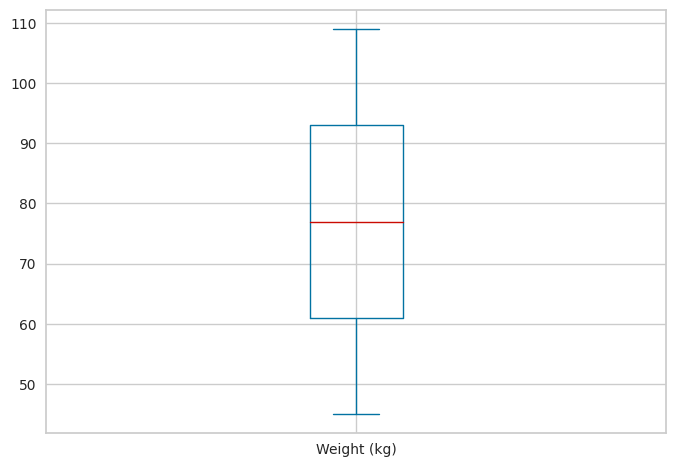

In [10]:
#exploramos la presencia de outliers: Weight (kg)
df['Weight (kg)'].plot(kind='box')

<Axes: >

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

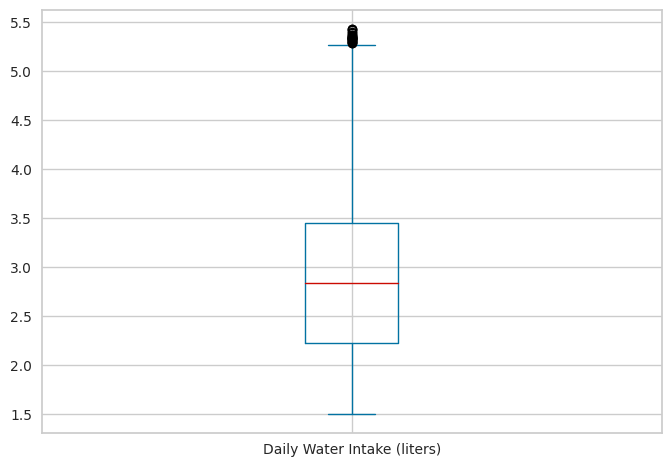

In [11]:
#exploramos la presencia de outliers: Daily Water Intake (liters)
df['Daily Water Intake (liters)'].plot(kind='box')

In [12]:
#imputamos los outliers con la mediana
df['Daily Water Intake (liters)'] = df['Daily Water Intake (liters)'].apply(lambda x: df['Daily Water Intake (liters)'].median() if x > 5.27 else x)

<Axes: >

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

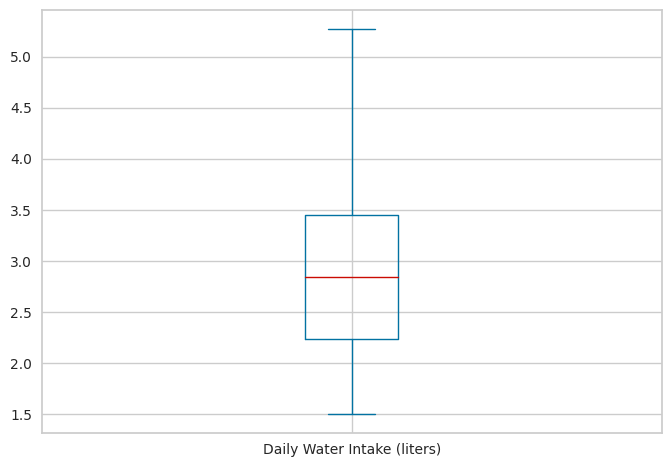

In [13]:

#validamos que ya no haya outliers
df['Daily Water Intake (liters)'].plot(kind='box')



In [14]:
#Comparamos tamaño inicial y final
print(df.shape)
print('Datos iniciales = ', tam_ini)
print('Datos finales = ', df.shape[0])

(29662, 7)
Datos iniciales =  30000
Datos finales =  29662


In [15]:
df['Hydration Level'].value_counts()

Hydration Level
Good    23730
Poor     5932
Name: count, dtype: int64

In [16]:
#Desbalance en %
(df['Hydration Level'].value_counts() / (df['Hydration Level'].value_counts().sum())*100).round(2)

Hydration Level
Good    80.0
Poor    20.0
Name: count, dtype: float64

In [17]:
#Transformar la dependiente a categorica numerica
df['Hydration_num'] = LabelEncoder().fit_transform(df['Hydration Level'])
df.sample(5)
# 0 = Good
# 1 = Poor

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level,Hydration_num
18278,35,Male,109,3.85,High,Normal,Good,0
28564,25,Male,58,1.50,Low,Normal,Poor,1
1639,69,Female,86,2.00,Low,Cold,Poor,1
607,27,Male,83,2.22,Low,Cold,Poor,1
20483,48,Female,103,3.82,Moderate,Normal,Good,0


In [18]:
#Transformar las independientes categoricas a numericas
df['Gender_num'] = LabelEncoder().fit_transform(df['Gender'])
df['Activity_num'] = LabelEncoder().fit_transform(df['Physical Activity Level'])
df['Weather_num'] = LabelEncoder().fit_transform(df['Weather'])
df.sample(5)

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level,Hydration_num,Gender_num,Activity_num,Weather_num
22286,31,Female,101,4.27,High,Hot,Good,0,0,0,1
7813,22,Female,51,2.62,Low,Hot,Good,0,0,1,1
2417,26,Male,92,3.68,High,Normal,Good,0,1,0,2
22580,41,Female,66,3.28,Moderate,Hot,Good,0,0,2,1
22653,30,Male,50,1.50,Low,Cold,Good,0,1,1,0


In [19]:
# Hay relacion lineal entre la variable dependiente y las variables independientes?
df.corr(numeric_only=True).sort_values('Hydration_num', ascending=False)

,Age,Weight (kg),Daily Water Intake (liters),Hydration_num,Gender_num,Activity_num,Weather_num
Hydration_num,0.123666,0.089104,-0.456417,1.000000,0.003001,0.154355,-0.169966
Activity_num,-0.007929,0.006216,-0.239551,0.154355,-0.003937,1.000000,0.001725
Age,1.000000,0.003592,-0.123533,0.123666,-0.003021,-0.007929,0.001355
Weight (kg),0.003592,1.000000,0.637930,0.089104,-0.009074,0.006216,-0.001187
Gender_num,-0.003021,-0.009074,-0.005848,0.003001,1.000000,-0.003937,-0.001203
Weather_num,0.001355,-0.001187,0.127001,-0.169966,-0.001203,0.001725,1.000000
Daily Water Intake (liters),-0.123533,0.637930,1.000000,-0.456417,-0.005848,-0.239551,0.127001


In [20]:
#Definir las x y las y
X = df.drop(['Gender', 'Physical Activity Level', 'Weather', 'Hydration Level', 'Hydration_num'], axis=1)
y = df['Hydration_num']
print(X.shape)
y.shape

(29662, 6)


(29662,)

In [21]:
#Dividir datos en Train test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((23729, 6), (5933, 6), (23729,), (5933,))

In [22]:
from imblearn.over_sampling import SMOTE

#Definimos la tecnica
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)
y_train_smote.value_counts()

Hydration_num
0    18984
1    18984
Name: count, dtype: int64

In [39]:
from imblearn.under_sampling import RandomUnderSampler

#Definimos la tecnica
rus = RandomUnderSampler(random_state=42)
x_train_rus, y_train_rus = rus.fit_resample(x_train, y_train)
y_train_rus.value_counts()

Hydration_num
0    4745
1    4745
Name: count, dtype: int64

In [24]:
#Entrenamos el modelo de Random Forest
#definimos el modelo
model_FS_SMOTE = RandomForestClassifier(random_state=42)
model_FS_RUS = RandomForestClassifier(random_state=42)

#Entrenamos los modelos
model_FS_SMOTE.fit(x_train_smote, y_train_smote)
model_FS_RUS.fit(x_train_rus, y_train_rus)

RandomForestClassifier(random_state=42)

In [25]:
#Evaluar rendimiento
accuracy_smote = model_FS_SMOTE.score(x_test, y_test)
accuracy_rus = model_FS_RUS.score(x_test, y_test)

#Mostramos los resultados
print('Accuracy SMOTE = ', accuracy_smote)
print('Accuracy RUS = ', accuracy_rus)

Accuracy SMOTE =  0.9882015843586718
Accuracy RUS =  0.9747176807685825


In [26]:
from imblearn.over_sampling import SMOTE

#Definimos la tecnica
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)
y_train_smote.value_counts()

Hydration_num
0    18984
1    18984
Name: count, dtype: int64

In [27]:
from imblearn.under_sampling import RandomUnderSampler

#Definimos la tecnica
rus = RandomUnderSampler(random_state=42)
x_train_rus, y_train_rus = rus.fit_resample(x_train, y_train)
y_train_rus.value_counts()

Hydration_num
0    4745
1    4745
Name: count, dtype: int64

In [28]:
#Entrenamos el modelo de Random Forest
#definimos el modelo
model_FS_SMOTE = RandomForestClassifier(random_state=42)
model_FS_RUS = RandomForestClassifier(random_state=42)

#Entrenamos los modelos
model_FS_SMOTE.fit(x_train_smote, y_train_smote)
model_FS_RUS.fit(x_train_rus, y_train_rus)

RandomForestClassifier(random_state=42)

In [29]:
#Evaluar rendimiento
accuracy_smote = model_FS_SMOTE.score(x_test, y_test)
accuracy_rus = model_FS_RUS.score(x_test, y_test)

#Mostramos los resultados
print('Accuracy SMOTE = ', accuracy_smote)
print('Accuracy RUS = ', accuracy_rus)

Accuracy SMOTE =  0.9882015843586718
Accuracy RUS =  0.9747176807685825


In [41]:
fi = pd.DataFrame({'Feature': list(X.columns),
                   'Importance': model_FS_SMOTE.feature_importances_}).sort_values('Importance', ascending=False)
#fi = pd.DataFrame({'Feature': list(X.columns), 'Importance': model_FS_RUS.feature_importances_}).sort_values('Importance', ascending=False)
#vemos los datos
fi

,Feature,Importance
2,Daily Water Intake (liters),0.359948
1,Weight (kg),0.238605
4,Activity_num,0.236655
5,Weather_num,0.121201
0,Age,0.039029
3,Gender_num,0.004562


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

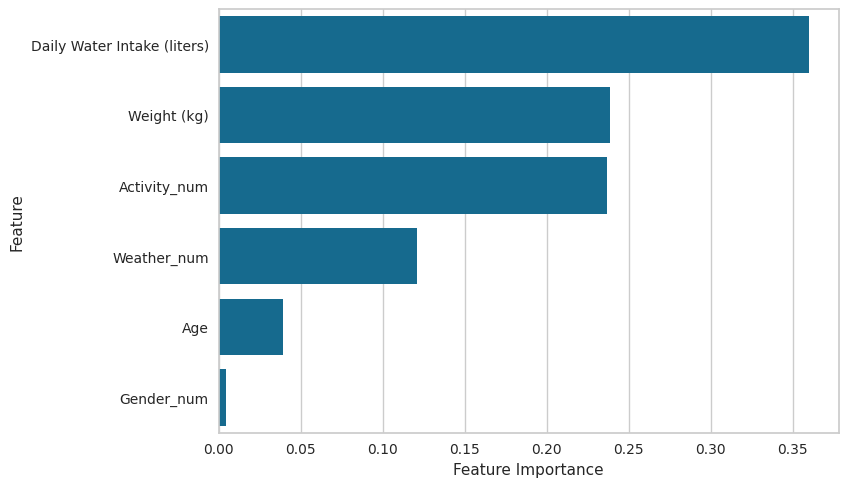

In [42]:
#Graficamos el FI
sns.barplot(y=fi['Feature'], x=fi['Importance'], orient='h')
plt.xlabel('Feature Importance')
plt.show()

In [43]:
#Con cuantas y cuales variables se logra contestar la VD?
fi.set_index('Feature', inplace=True)
fi_sum = fi.cumsum(axis=0)
fi_sum

,Importance
Feature,
Daily Water Intake (liters),0.359948
Weight (kg),0.598553
Activity_num,0.835209
Weather_num,0.956409
Age,0.995438
Gender_num,1.000000
